# Prepare the Environment

In [1]:
############ CREATE VIRTUAL ENVIRONMENT ############

## Python 3.8.16

## From terminal;
# python -m venv scorecard_env
# source scorecard_env/bin/activate
# pip install jupyterlab ipykernel ipywidgets
# which python3

In [34]:
############ ADD VENV TO JUPYTER NOTEBOOK VENV LIST ############

# python -m ipykernel install --user --name=scorecard_env
## Restart kernel to activate

In [35]:
############ ACTIVATE VIRTUAL ENV ############

# jupyter kernelspec list
# which python3

In [36]:
############ UNINSTALL VIRTUAL ENV ############

## If you need to remove a venv;
# jupyter kernelspec uninstall scorecard_env

In [37]:
############ INSTALL REQUIRED PACKAGES ############

## The below lines of code first upgrade the pip library, then install the libraries specified in requirements.txt
# pip install --upgrade pip
# pip install -r requirements.txt

In [38]:
############ IMPORT LIBRARIES ############

from QNBAnalytics_ML import data
from QNBAnalytics_ML import skills_api
from QNBAnalytics_ML.feature_importances import plot_feature_importances
from QNBAnalytics_ML.param_grid_best import grids as param_grid_best
import pandas as pd
import numpy as np
import pickle
import datetime

version = "training"
start_time = datetime.datetime.now()

In [39]:
############ ENTER PARAMETERS ############

index_col = "MUQAVILE"  # index column
target_col = "TARGET"  # target column


## (OPTIONAL)

cols_to_drop = ["CC_O_4M6MWPS_EVER","ALL_O_4M6MWPS_EVER_O","ALL_O_7M12MWPS_EVER","ALL_O_7M12MWPS_EVER_O","ALL_OSMLMT_CWPS1_6_EVER","CC_O_13M24MWPS_EVER","CC_O_13M24MWPS_EVER_O","CC_O_7M12MWPS_EVER","CC_O_7M12MWPS_EVER_O","CCOL_O_4M6MWPS_EVER","CL_O_13M24MWPS_EVER_O","HL_EVERWPS_EVER","HL_O_13M24MWPS_365DP","HL_O_3MWPS_365DP","HL_O_4M6MWPS_EVER_O","HL_O_7M12MWPS_EVER_O","HL_O_EVERWPS_365DP","OL_O_3MWPS_183D365D","OL_O_3MWPS_365DP","OL_O_4M6MWPS_183D365D","OL_O_4M6MWPS_91D182D","OL_O_7M12MWPS_365DP","OL_O_EVERWPS_183D365D","OL_O_EVERWPS_365DP","OL_O_EVERWPS_90D","OL_O_EVERWPS_91D182D","OL_OLMTUTL_CWPS0_90D_O","BGN"]


In [40]:
############ (OPTIONAL) DATA ORDER IN THE FINAL VERSION ############
############ TO GET THE SAME OUTPUT AS IN FINAL VERSION ############
sorted_indices = pd.read_excel("Data/sorted_indices.xlsx")
sorted_indices_train = sorted_indices.iloc[:85955,0].values
sorted_indices_test = sorted_indices.iloc[85955:,0].values

In [41]:
############ READ DATA FROM DATABASE ############

database_username = pd.read_table('Data/user', header = None)[0][0]  # enter your db username
database_password = pd.read_table('Data/pass', header = None)[0][0]  # enter your database password
engine=data.connect_to_sql(database_username, database_password)

with open(f'Data/train_data_sql_{version}.txt') as f: train_data_sql = f.read()
train = data.data_load(engine, sql = train_data_sql) 

train = train.set_index(index_col).rename(columns={target_col: "TARGET"})
train = train.reindex(sorted_indices_train) ## TO GET THE SAME OUTPUT AS IN FINAL VERSION
y_train = train["TARGET"]
x_train = train.drop(columns=["TARGET"]+cols_to_drop, inplace=False)



############ READ TEST (HOLDOUT) DATA ############

engine=data.connect_to_sql(database_username, database_password)
with open(f'Data/test_data_sql_{version}.txt') as f:  test_data_sql = f.read()
test = data.data_load(engine, sql = test_data_sql)

test = test.set_index(index_col).rename(columns={target_col: "TARGET"})
test = test.reindex(sorted_indices_test) ## TO GET THE SAME OUTPUT AS IN FINAL VERSION
y_test = test["TARGET"]
x_test = test.drop(columns=["TARGET"]+cols_to_drop, inplace=False)

2024-02-09 15:18:15,587 - qnbanalytics - INFO - Connected!

2024-02-09 15:20:43,895 - qnbanalytics - INFO - Dataframe created!

2024-02-09 15:20:43,897 - qnbanalytics - INFO - (85955, 2736)
2024-02-09 15:20:48,898 - qnbanalytics - INFO - Connected!

2024-02-09 15:21:13,833 - qnbanalytics - INFO - Dataframe created!

2024-02-09 15:21:13,835 - qnbanalytics - INFO - (10734, 2736)


In [42]:
## PIPELINE SETTINGS

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_low_gini_elimination = True
apply_correlated_feature_elimination = True
apply_binning = True
apply_scaling = False
apply_null_imputation = False
apply_categorical_encoding = False

apply_LR = True

In [43]:
############ CREATE PIPELINE ############

class Pipeline_Base:
  
    
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()
        
        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)

        ########################   Data Explore    ############################ 
        
        if apply_data_explore:
            self.pipeline.data_explore()
                                  
        
        ########################   Drop Null Features    ############################ 
        
        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})
          
          
        ########################   Drop Constant Features    ############################ 
        
        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})
                                  
                                  
        ########################   Low Gini Elimination    ############################ 
        
        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})
            

        ########################   Feature Elimination    ############################ 
        
        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})
            
            
        ########################   Binning    ############################ 
        
        if apply_binning:
            self.pipeline.binning(use_existing = 'binning.pkl') ## USE EXISTING BINNING (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 
                   

        ########################   Scaling    ############################ 
        
        if apply_scaling:
            self.pipeline.scaling()
                   

        ########################   Null Imputation    ############################ 
        
        if apply_null_imputation:
            self.pipeline.null_imputation()
                   

        ########################   Categorical Encoding    ############################ 
        
        if apply_categorical_encoding:
            self.pipeline.encode_categoricals()
                   

        #########################      Logistic Regression      #############################
        
        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_base']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 

            
    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

2024-02-09 15:21:26,224 - qnbanalytics - INFO - There might be multiple ID in dataframe
2024-02-09 15:21:31,801 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:21:31,802 - qnbanalytics - INFO - Data Type Conversion completed
2024-02-09 15:21:31,987 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:21:31,989 - qnbanalytics - INFO - Data Type Conversion completed
2024-02-09 15:21:32,959 - qnbanalytics - INFO - Feature Elimination Started: drop_null_features
2024-02-09 15:21:36,548 - qnbanalytics - INFO - Feature Elimination completed.
2024-02-09 15:21:46,344 - qnbanalytics - INFO - No ID detected!

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
2024-02-09 15:21:49,959 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:21:49,

Fitting 3 folds for each of 1 candidates, totalling 3 fits


2024-02-09 15:25:18,456 - qnbanalytics - INFO - Refitting to all data...
2024-02-09 15:25:19,674 - qnbanalytics - INFO - Results of LogisticRegression(C=0.03726121757536122, random_state=48)
2024-02-09 15:25:19,675 - qnbanalytics - INFO - Mean CV score:  0.5677272095325383
2024-02-09 15:25:19,675 - qnbanalytics - INFO - Calculating SHAP feature importances...
Model is linear, disabling fast option...
Your model is LogisticRegression(C=0.03726121757536122, random_state=48)
If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
2024-02-09 15:25:19,961 - qnbanalytics - INFO - Model fitting completed.

2024-02-09 15:25:20,026 - qnbanalytics - INFO - With ROC: 
2024-02-09 15:25:20,026 - qnbanalytics - INFO - With gini: 
2024-02-09 15:25:20,043 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:25:20,044 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:25:20,044 - qnbanalyt

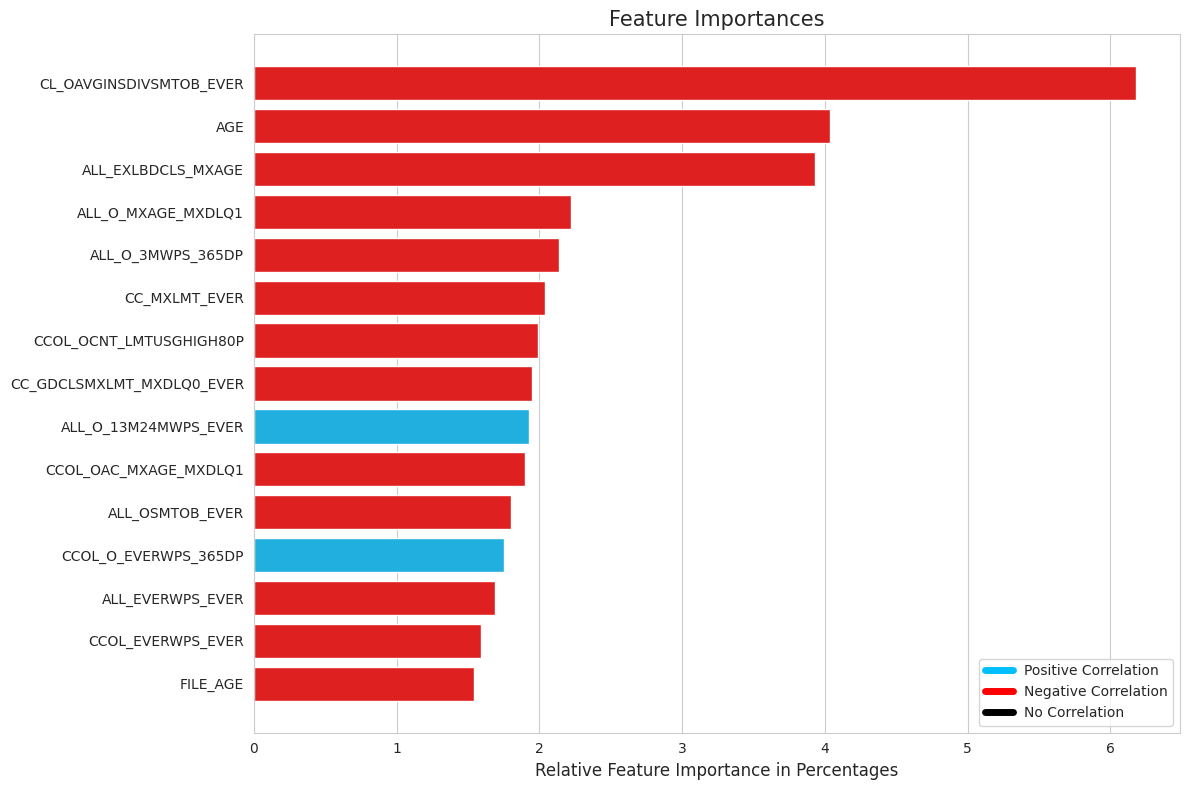

In [44]:
############ TRAIN MODEL ############

pipeline_base = Pipeline_Base()
pipeline_base.train(x_train = x_train, y_train = y_train,
                      x_test = x_test, y_test = y_test)

drop_null_eliminated_features: 424
drop_constant_eliminated_features: 144
low_gini_eliminated_features: 1139
correlation_elimination_eliminated_features: 766
used features: 233


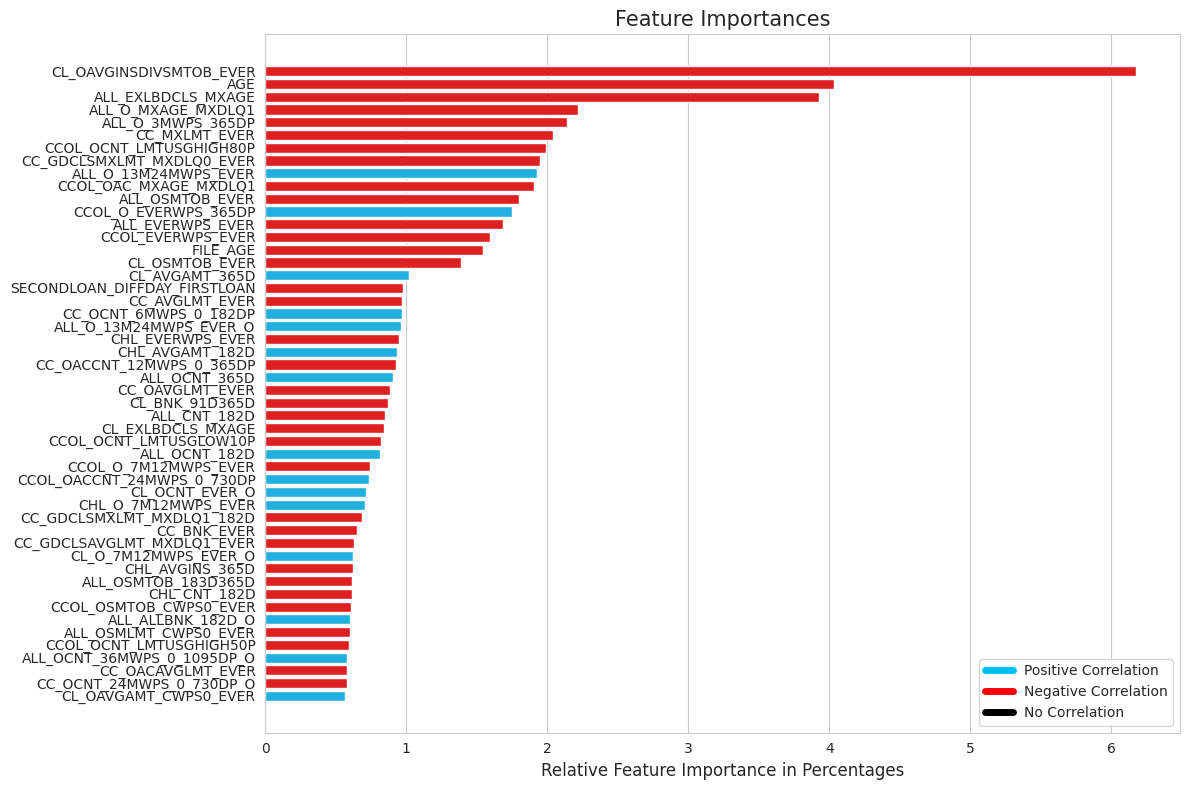

In [45]:
############ SAVE MODEL ############

model_path = f'Models/base_model_{version}.pkl'
with open(model_path, 'wb') as out:
    pickle.dump(pipeline_base.pipeline, out, pickle.HIGHEST_PROTOCOL)


############ LOAD MODEL ############

# model_path = f'Models/base_model_{version}.pkl'
# with open(model_path, 'rb') as f:
#   pipeline_base = pickle.load(f)




############ FEATURE IMPORTANCE ############
plot_feature_importances(df=pipeline_base.pipeline.logistic_regression_model.model.feature_importances,
                          n=50,
                          save_figure=True,
                          name_ext=f"Base_{version}")


feature_importances = pipeline_base.pipeline.logistic_regression_model.model.feature_importances
pd.DataFrame(feature_importances).to_excel(f"Output/FEATURE_IMPORTANCES_BASE_{version}.xlsx")



binning_table = pipeline_base.pipeline.monotonic_binning.get_binning_table()
pd.DataFrame(binning_table[0]).to_excel(f"Output/BINNING_TABLE_BASE_{version}.xlsx")
pd.DataFrame(binning_table[1]).to_excel(f"Output/GINI_TABLE_BASE_{version}.xlsx")





############ ELIMINATED FEATURES ############

variable_table = pipeline_base.pipeline.variable_table
pd.DataFrame(variable_table).to_excel(f"Output/FEATURES_BASE_{version}.xlsx")


drop_null_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_null_features']
drop_constant_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_constant_features']
low_gini_eliminated_features = pipeline_base.pipeline.eliminated_features['drop_low_gini_features']
correlation_elimination_eliminated_features = pipeline_base.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(drop_null_eliminated_features, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(drop_constant_eliminated_features, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_BASE_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_BASE_{version}.xlsx")


print(
"""drop_null_eliminated_features: %d
drop_constant_eliminated_features: %d
low_gini_eliminated_features: %d
correlation_elimination_eliminated_features: %d
used features: %d""" % (len(drop_null_eliminated_features), len(drop_constant_eliminated_features), len(low_gini_eliminated_features), len(correlation_elimination_eliminated_features), sum(variable_table.use == True)))

In [46]:
############ PERFORMANCE OF THE BASE MODEL (LAYER_1) ############

############ BASIC PIPELINE RESULTS ############

base_test_proba_dict = pipeline_base.apply(x_test, y_test)
base_test_proba = base_test_proba_dict["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]

2024-02-09 15:25:27,395 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:25:27,396 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:25:27,397 - qnbanalytics - INFO - CV gini: 0.5677272095325383
2024-02-09 15:25:27,397 - qnbanalytics - INFO - Valid gini: 0.5630992553492318
2024-02-09 15:25:27,398 - qnbanalytics - INFO - Test gini: 0.5630992553492318



In [47]:
############ CALCULATE CREDIT SCORES ############

all_x = pd.concat([x_train,x_test], axis = 0)
all_y = pd.concat([y_train,y_test], axis = 0)

base_all_proba = pipeline_base.apply(all_x, all_y)["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]
base_all_proba = pd.DataFrame(base_all_proba, index = all_y.index)


ref=200
odds_at_ref=50
points_to_double=20


default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)



base_all_scores = pd.concat([base_all_proba, base_all_score, all_y], axis = 1)
base_all_scores.columns = ["PROBA","SCORE","TARGET"]
pd.DataFrame(base_all_scores).to_excel(f"Output/MAIN_SCORES_BASE_{version}.xlsx")

print("Base model took: %s" % (datetime.datetime.now()- start_time))

2024-02-09 15:25:39,191 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:25:39,192 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:25:39,193 - qnbanalytics - INFO - CV gini: 0.5677272095325383
2024-02-09 15:25:39,194 - qnbanalytics - INFO - Valid gini: 0.5630992553492318
2024-02-09 15:25:39,194 - qnbanalytics - INFO - Test gini: 0.5966651358958048



Base model took: 0:07:37.012518


In [48]:
############ BEGINNING OF THE ADVANCED PIPELINE ############

############ SPLIT DATA FOR LAYER_2 MODELS ############

good_score_threshold = 180 # goods: 180+ scores 
not_good_score_threshold = 200 # not_goods: 200- scores 
good_threshold = 1 / (np.exp((good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)  
not_good_threshold = 1 / (np.exp((not_good_score_threshold-ref) / (points_to_double) * np.log(2) + np.log(odds_at_ref)) + 1)  

train_preds = pipeline_base.apply(x_train, y_test = y_train)
not_good_indices = train_preds["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0] >= not_good_threshold
good_indices = train_preds["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0] < good_threshold


print("Not Good split:\n", pd.concat([train[not_good_indices].TARGET.value_counts(), train[not_good_indices].TARGET.value_counts(normalize=True)], axis = 1))
print("Good split:\n", pd.concat([train[good_indices].TARGET.value_counts(), train[good_indices].TARGET.value_counts(normalize=True)], axis = 1))

train_not_good = train[not_good_indices]
train_good = train[good_indices]

y_train_not_good = train_not_good["TARGET"]
y_train_good = train_good["TARGET"]

x_train_not_good = train_not_good.drop(columns=["TARGET"]+cols_to_drop, inplace=False)
x_train_good = train_good.drop(columns=["TARGET"]+cols_to_drop, inplace=False)

2024-02-09 15:25:56,933 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:25:56,934 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:25:56,934 - qnbanalytics - INFO - CV gini: 0.5677272095325383
2024-02-09 15:25:56,935 - qnbanalytics - INFO - Valid gini: 0.5630992553492318
2024-02-09 15:25:56,935 - qnbanalytics - INFO - Test gini: 0.597644163943863



Not Good split:
    TARGET    TARGET
0   23689  0.951404
1    1210  0.048596
Good split:
    TARGET    TARGET
0   74297  0.989005
1     826  0.010995


In [49]:
############ CREATE PIPELINE FOR LAYER_2 MODELS ############

apply_data_explore = True
apply_null_elimination = True
apply_constant_elimination = True
apply_low_gini_elimination = True
apply_correlated_feature_elimination = True
apply_binning = False
apply_scaling = True
apply_null_imputation = True
apply_categorical_encoding = True

apply_LR = True
apply_RF = True
apply_XGB = True
apply_LGBM = True

In [50]:
class Pipeline_Not_Good:
    
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()
        
        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)
        
        ########################   Data Explore    ############################ 
        
        if apply_data_explore:
            self.pipeline.data_explore()
                                  
        
        ########################   Drop Null Features    ############################ 
        
        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})
          
          
        ########################   Drop Constant Features    ############################ 
        
        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})
                                  
                                  
        ########################   Low Gini Elimination    ############################ 
        
        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})
            

        ########################   Feature Elimination    ############################ 
        
        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})
            
            
        ########################   Binning    ############################ 
        
        if apply_binning:
            self.pipeline.binning()
                   

        ########################   Scaling    ############################ 
        
        if apply_scaling:
            self.pipeline.scaling()
                   

        ########################   Null Imputation    ############################ 
        
        if apply_null_imputation:
            self.pipeline.null_imputation()
                   

        ########################   Categorical Encoding    ############################ 
        
        if apply_categorical_encoding:
            self.pipeline.encode_categoricals()
                   

        #########################      Logistic Regression      #############################
        
        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_not_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_not_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 

        #########################        XGBoost          #############################
        
        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_not_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 
        
        #########################      LGBM      #############################
        
        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_not_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 
            
    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

In [51]:
class Pipeline_Good:
    
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()
        
        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)
        
        ########################   Data Explore    ############################ 
        
        if apply_data_explore:
            self.pipeline.data_explore()
                                  
        
        ########################   Drop Null Features    ############################ 
        
        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})
          
          
        ########################   Drop Constant Features    ############################ 
        
        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})
                                  
                                  
        ########################   Low Gini Elimination    ############################ 
        
        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})
            

        ########################   Feature Elimination    ############################ 
        
        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})
            
            
        ########################   Binning    ############################ 
        
        if apply_binning:
            self.pipeline.binning()
                   

        ########################   Scaling    ############################ 
        
        if apply_scaling:
            self.pipeline.scaling()
                   

        ########################   Null Imputation    ############################ 
        
        if apply_null_imputation:
            self.pipeline.null_imputation()
                   

        ########################   Categorical Encoding    ############################ 
        
        if apply_categorical_encoding:
            self.pipeline.encode_categoricals()
                   

        #########################      Logistic Regression      #############################
        
        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 

        #########################      Random Forest      #############################

        if apply_RF:
            self.pipeline.RandomForest(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['random_forest_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 

        #########################        XGBoost          #############################
        
        if apply_XGB:
            self.pipeline.XGBoost(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['xgboost_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 
        
        #########################      LGBM      #############################
        
        if apply_LGBM:
            self.pipeline.LGBM(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['lightgbm_good']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 
            
    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

2024-02-09 15:26:02,925 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:26:02,926 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:26:02,927 - qnbanalytics - INFO - CV gini: 0.5677272095325383
2024-02-09 15:26:02,927 - qnbanalytics - INFO - Valid gini: 0.5630992553492318
2024-02-09 15:26:02,927 - qnbanalytics - INFO - Test gini: 0.5630992553492318

2024-02-09 15:26:08,676 - qnbanalytics - INFO - There might be multiple ID in dataframe
2024-02-09 15:26:10,360 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:26:10,362 - qnbanalytics - INFO - Data Type Conversion completed
2024-02-09 15:26:10,433 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:26:10,435 - qnbanalytics - INFO - Data Type Conversion completed
2024-02-09 15:26:10,957 - qnbanalytics - INFO - Feature Elimination Started: drop_null_features
2024-02-09 15:26:12,029 - qnbanalytics - INFO - Feature Elimination completed.
2024-02-09 15:26:16,507 - qnbanaly

Encoding completed.



2024-02-09 15:26:48,194 - qnbanalytics - INFO - No ID detected!
2024-02-09 15:26:48,260 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:26:48,261 - qnbanalytics - INFO - Data Type Conversion completed
2024-02-09 15:26:48,287 - qnbanalytics - INFO - 

2024-02-09 15:26:48,288 - qnbanalytics - INFO - Logistic Regression fitting started.

2024-02-09 15:26:48,290 - qnbanalytics - INFO - This is a binary classification problem.

2024-02-09 15:26:48,328 - qnbanalytics - INFO - Parameter optimization started.

The total space of parameters 1 is smaller than n_iter=15. Running 1 iterations. For exhaustive searches, use GridSearchCV.


Fitting 3 folds for each of 1 candidates, totalling 3 fits


2024-02-09 15:26:48,800 - qnbanalytics - INFO - Refitting to all data...
2024-02-09 15:26:48,962 - qnbanalytics - INFO - Results of LogisticRegression(C=0.02436512422392614, random_state=48)
2024-02-09 15:26:48,963 - qnbanalytics - INFO - Mean CV score:  0.20248166557174918
2024-02-09 15:26:48,963 - qnbanalytics - INFO - Calculating SHAP feature importances...
Model is linear, disabling fast option...
Your model is LogisticRegression(C=0.02436512422392614, random_state=48)
If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
2024-02-09 15:26:49,060 - qnbanalytics - INFO - Model fitting completed.

2024-02-09 15:26:49,086 - qnbanalytics - INFO - With ROC: 
2024-02-09 15:26:49,087 - qnbanalytics - INFO - With gini: 
2024-02-09 15:26:49,093 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:26:49,093 - qnbanalytics - INFO - Train gini: 0.299544266631407
2024-02-09 15:26:49,094 - qnbanaly

...

2024-02-09 15:30:19,159 - qnbanalytics - INFO - Refitting to all data...


[27]	valid_0's auc: 0.674163	valid_0's binary_logloss: 0.0580384
[28]	valid_0's auc: 0.671829	valid_0's binary_logloss: 0.0580544
[29]	valid_0's auc: 0.670573	valid_0's binary_logloss: 0.0580822
[30]	valid_0's auc: 0.671784	valid_0's binary_logloss: 0.0580869
[31]	valid_0's auc: 0.672907	valid_0's binary_logloss: 0.0580673
[32]	valid_0's auc: 0.672372	valid_0's binary_logloss: 0.0580891
[1]	valid_0's auc: 0.667112	valid_0's binary_logloss: 0.053225
[2]	valid_0's auc: 0.67401	valid_0's binary_logloss: 0.0530349
[3]	valid_0's auc: 0.665746	valid_0's binary_logloss: 0.0528606
[4]	valid_0's auc: 0.679257	valid_0's binary_logloss: 0.052689
[5]	valid_0's auc: 0.684881	valid_0's binary_logloss: 0.0525229
[6]	valid_0's auc: 0.674559	valid_0's binary_logloss: 0.0524571
[7]	valid_0's auc: 0.663224	valid_0's binary_logloss: 0.052373
[8]	valid_0's auc: 0.660989	valid_0's binary_logloss: 0.0523655
[9]	valid_0's auc: 0.659074	valid_0's binary_logloss: 0.0523334
[10]	valid_0's auc: 0.665625	valid_0's

2024-02-09 15:30:20,706 - qnbanalytics - INFO - Results of LGBMClassifier(colsample_bytree=0.8, early_stopping_round=10,
               first_metric_only=True, max_depth=6, min_child_samples=370,
               n_estimators=10000, n_jobs=1, num_leaves=12, random_state=48,
               reg_alpha=1.7786201857096935e-08,
               reg_lambda=0.0003320897385975011, subsample=0.9,
               subsample_freq=1)
2024-02-09 15:30:20,707 - qnbanalytics - INFO - Mean CV score:  0.36486861014908256
2024-02-09 15:30:20,708 - qnbanalytics - INFO - Calculating SHAP feature importances...
Your model is LGBMClassifier(colsample_bytree=0.8, early_stopping_round=10,
               first_metric_only=True, max_depth=6, min_child_samples=370,
               n_estimators=10000, n_jobs=1, num_leaves=12, random_state=48,
               reg_alpha=1.7786201857096935e-08,
               reg_lambda=0.0003320897385975011, subsample=0.9,
               subsample_freq=1)
If your model is not TreeBased, Lin

[14]	valid_0's auc: 0.670206	valid_0's binary_logloss: 0.0520999
[15]	valid_0's auc: 0.668358	valid_0's binary_logloss: 0.0520959


2024-02-09 15:30:20,950 - qnbanalytics - INFO - With ROC: 
2024-02-09 15:30:20,950 - qnbanalytics - INFO - With gini: 
2024-02-09 15:30:20,977 - qnbanalytics - INFO - Results of LGBM
2024-02-09 15:30:20,977 - qnbanalytics - INFO - Train gini: 0.46662412206541903
2024-02-09 15:30:20,978 - qnbanalytics - INFO - CV gini: 0.36486861014908256
2024-02-09 15:30:20,978 - qnbanalytics - INFO - Valid gini: 0.3711463624286946
2024-02-09 15:30:20,979 - qnbanalytics - INFO - Test gini: None

2024-02-09 15:30:21,484 - qnbanalytics - INFO - No ID detected!

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


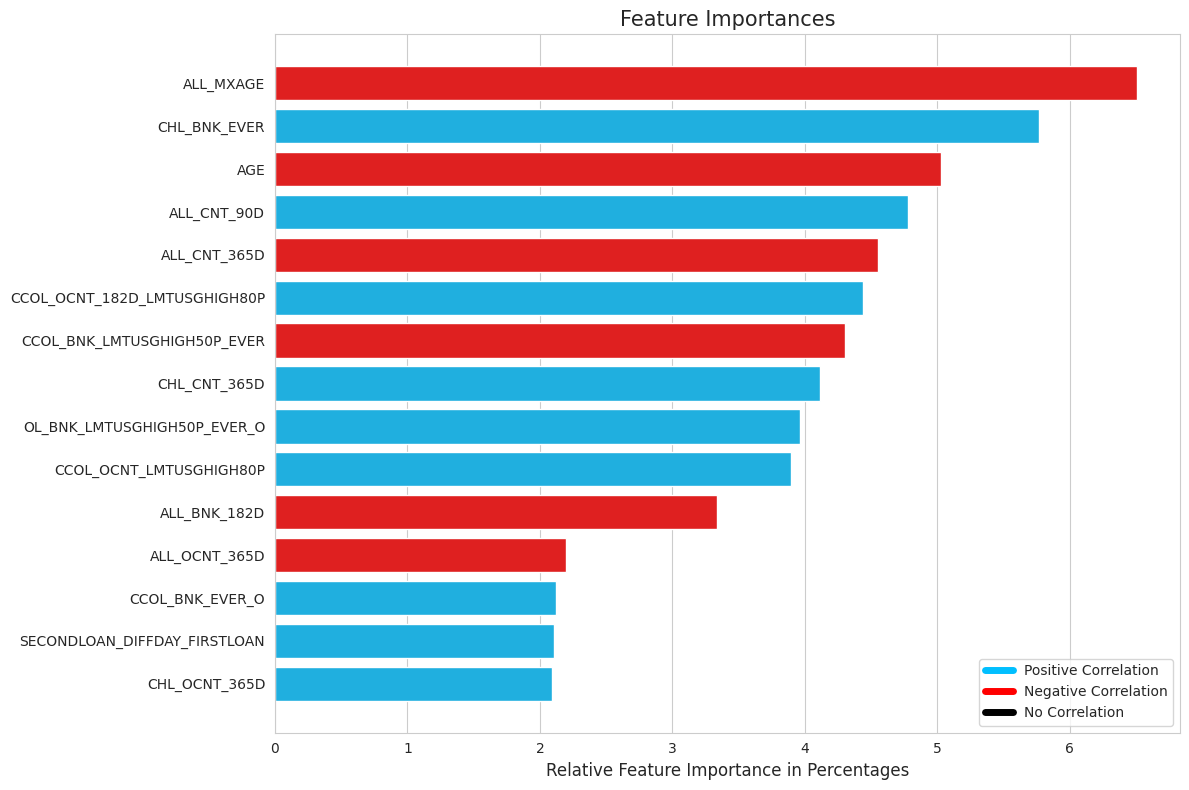

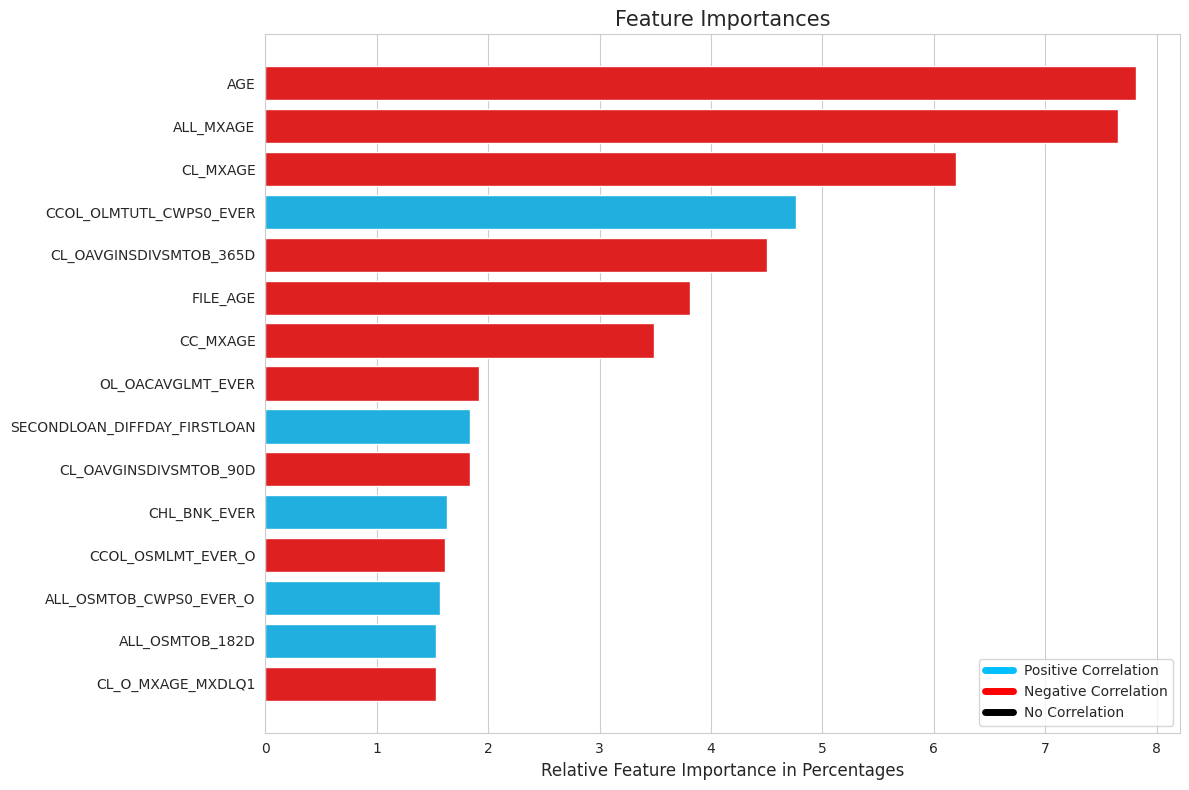

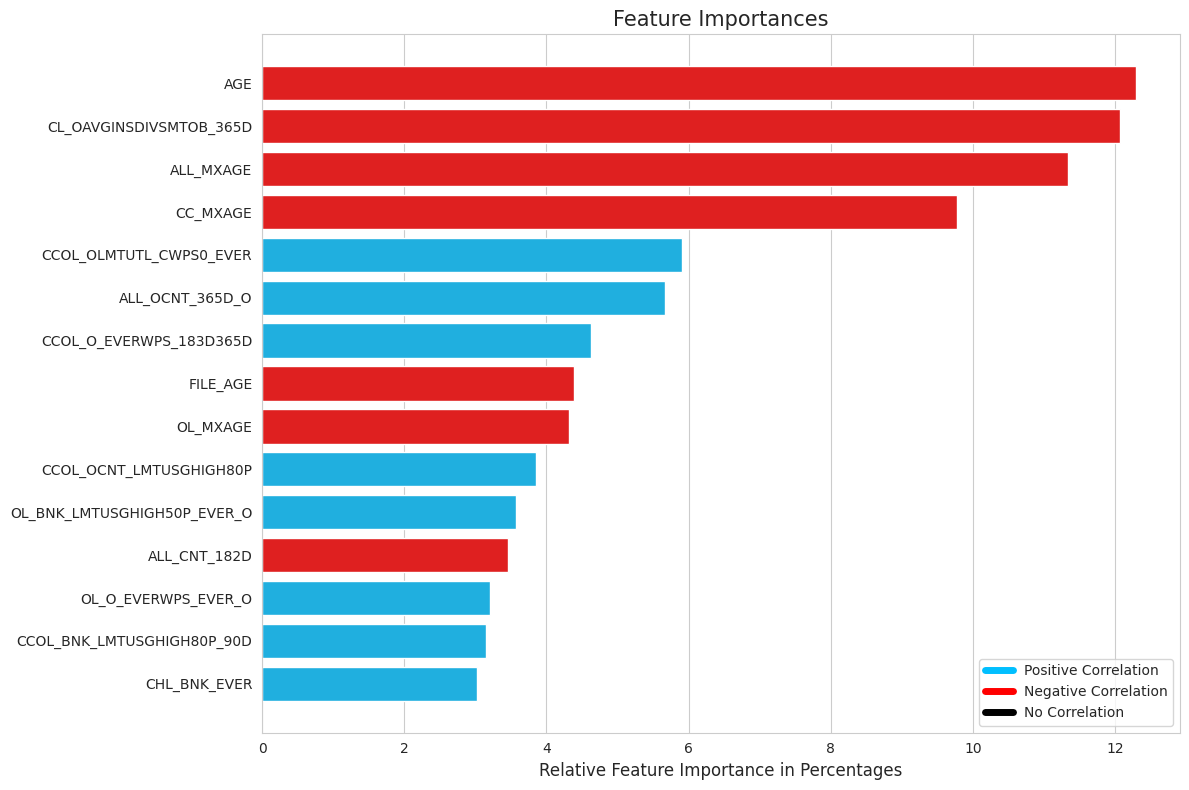

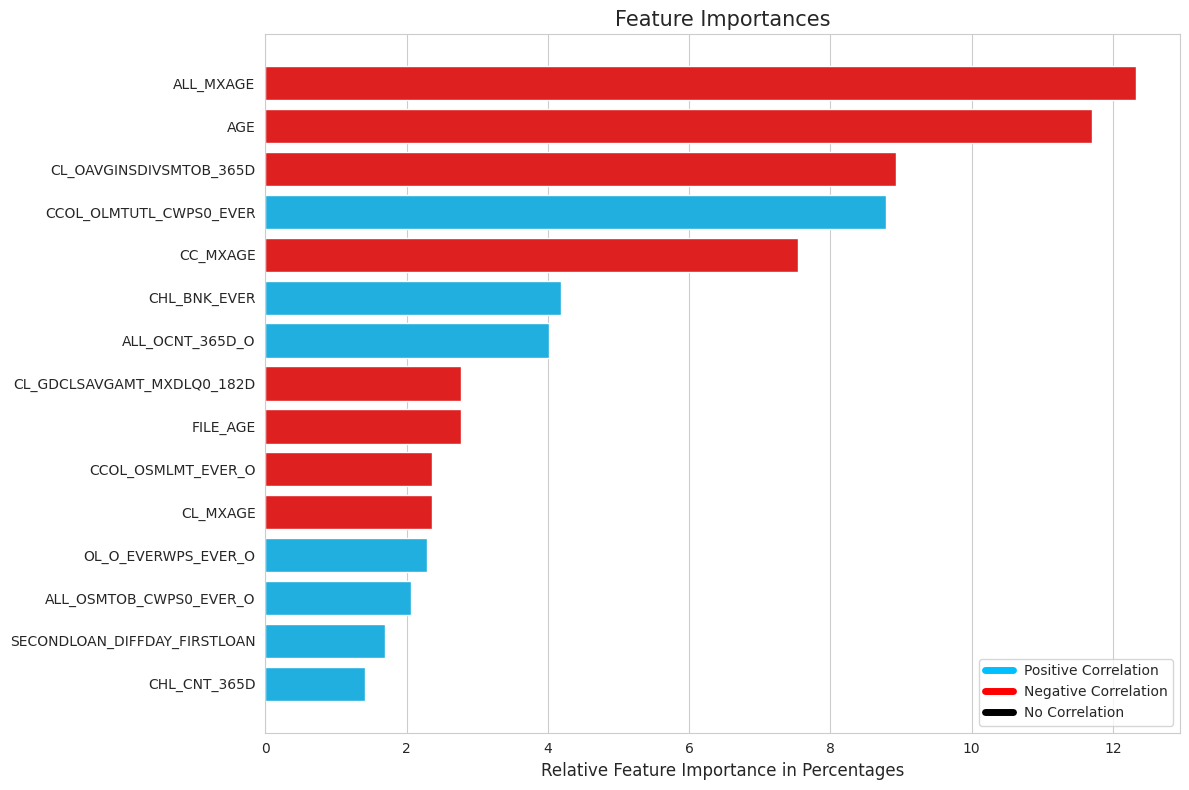

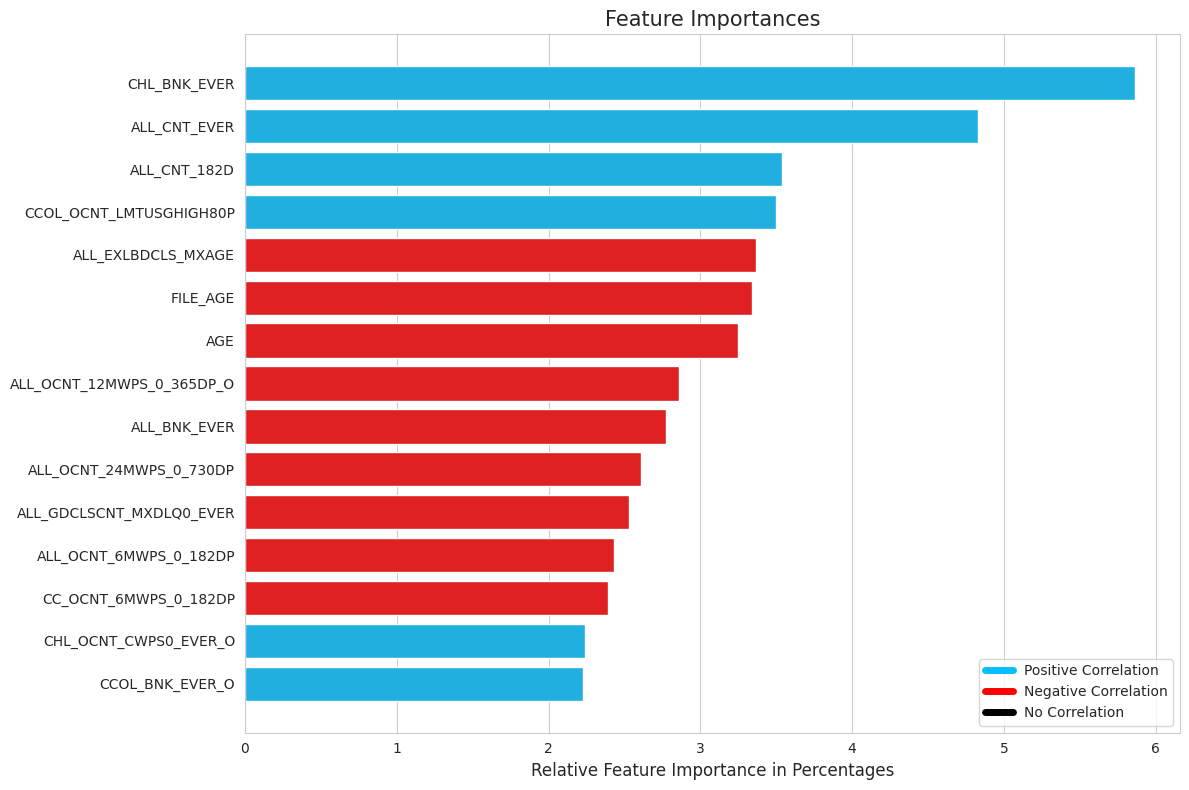

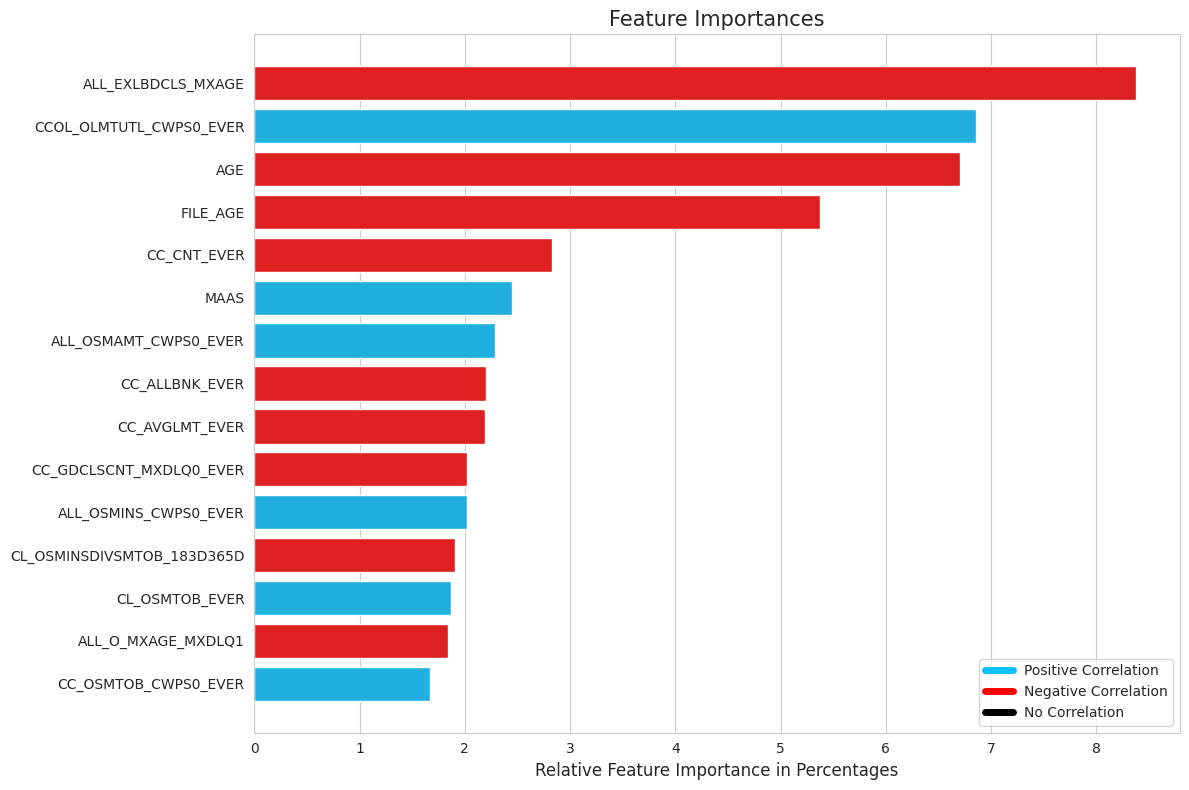

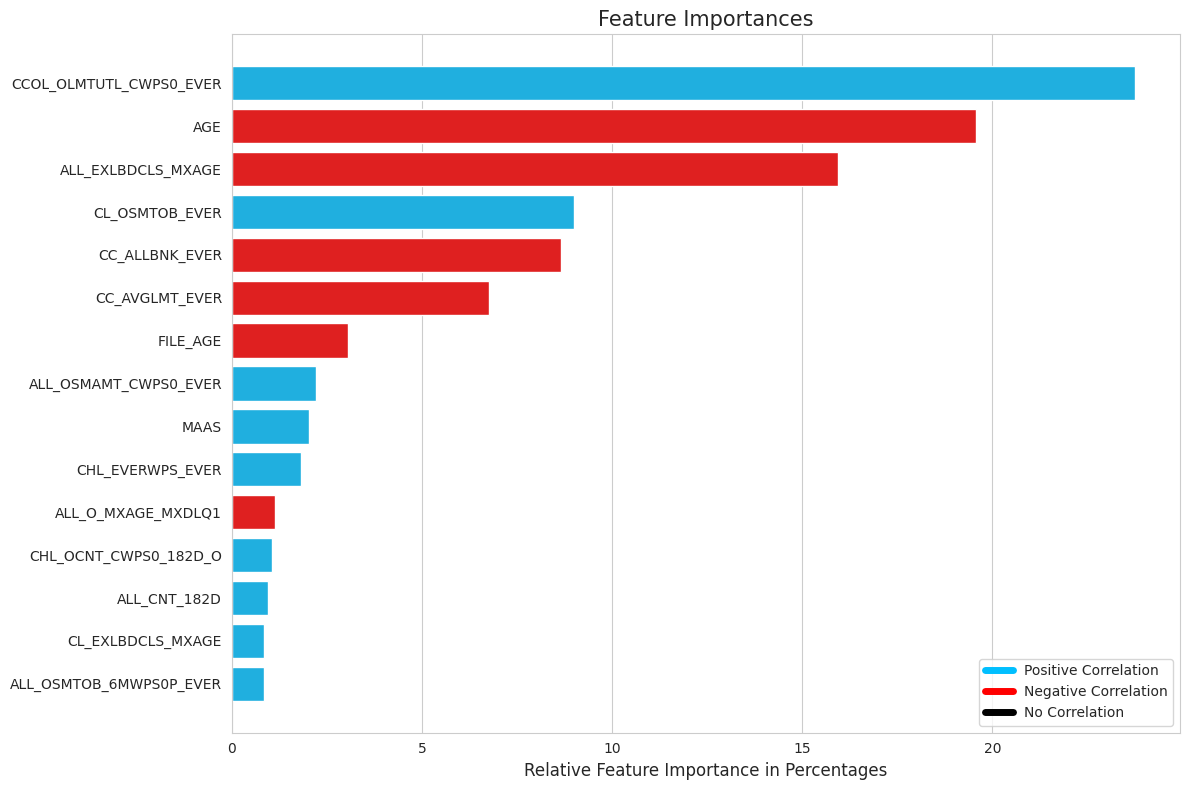

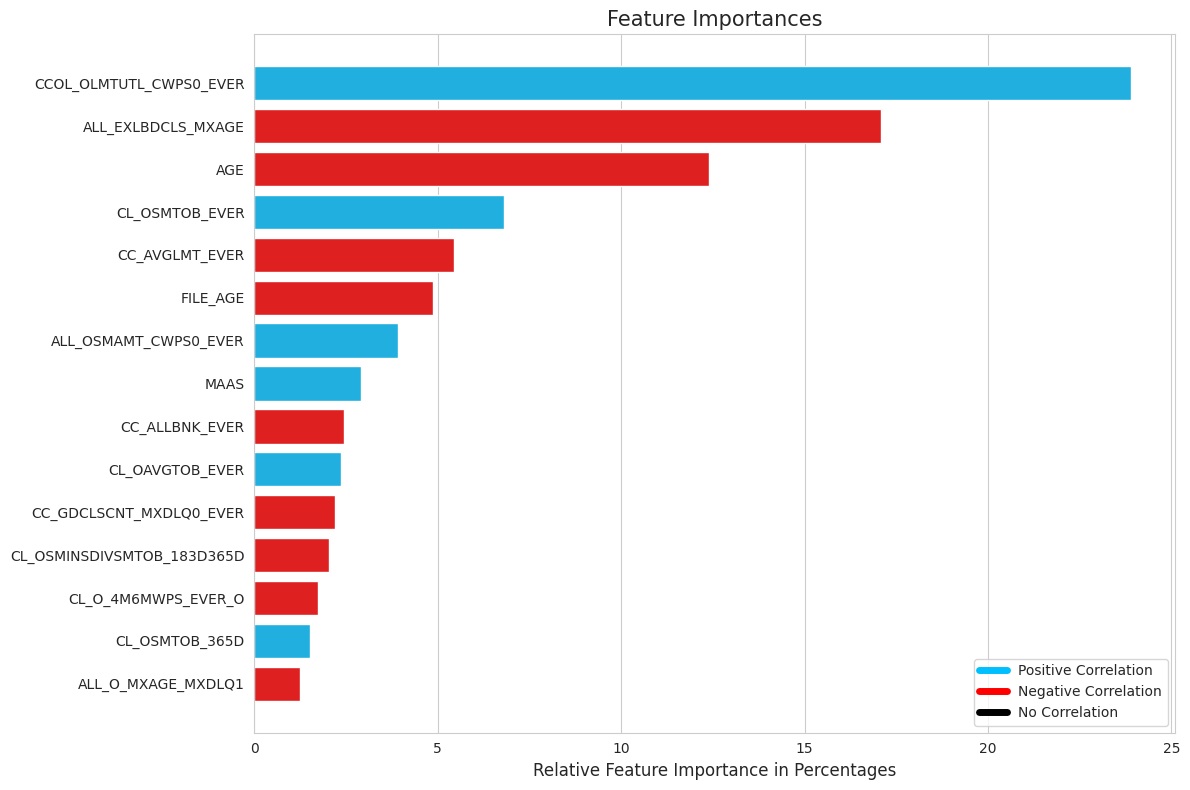

In [52]:
############ CREATE TEST DATA FOR LAYER_2 MODELS ############
test_preds = pipeline_base.apply(x_test = x_test, y_test = y_test)
not_good_indices_test = test_preds["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0] >= not_good_threshold
good_indices_test = test_preds["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0] < good_threshold

test_not_good = test[not_good_indices_test]
test_good = test[good_indices_test]

y_test_not_good = test_not_good["TARGET"]
y_test_good = test_good["TARGET"]

x_test_not_good = test_not_good.drop(columns=["TARGET"]+cols_to_drop, inplace=False)
x_test_good = test_good.drop(columns=["TARGET"]+cols_to_drop, inplace=False)

############ TRAIN LAYER_2 MODELS ############

pipeline_not_good = Pipeline_Not_Good()
pipeline_not_good.train(x_train=x_train_not_good, y_train=y_train_not_good, x_test = x_test_not_good, y_test = y_test_not_good)

pipeline_good = Pipeline_Good()
pipeline_good.train(x_train=x_train_good, y_train=y_train_good, x_test = x_test_good, y_test = y_test_good)

In [53]:
############ SELECT BEST MODELS FOR LAYER_2 ############

pipeline_not_good.apply(x_test_not_good, y_test_not_good)
pipeline_good.apply(x_test_good, y_test_good)


2024-02-09 15:30:23,222 - qnbanalytics - INFO - Scaling started...

2024-02-09 15:30:23,226 - qnbanalytics - INFO - Scaling completed.

2024-02-09 15:30:23,264 - qnbanalytics - INFO - Imputation transform started...
2024-02-09 15:30:23,269 - qnbanalytics - INFO - Imputation transform completed...
2024-02-09 15:30:23,273 - qnbanalytics - INFO - Encoding started...

2024-02-09 15:30:23,275 - qnbanalytics - INFO - Encoding completed.

2024-02-09 15:30:23,281 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:30:23,282 - qnbanalytics - INFO - Train gini: 0.299544266631407
2024-02-09 15:30:23,282 - qnbanalytics - INFO - CV gini: 0.20248166557174918
2024-02-09 15:30:23,283 - qnbanalytics - INFO - Valid gini: 0.3413123723509901
2024-02-09 15:30:23,283 - qnbanalytics - INFO - Test gini: 0.3413123723509901

2024-02-09 15:30:23,344 - qnbanalytics - INFO - Results of Random Forest
2024-02-09 15:30:23,345 - qnbanalytics - INFO - Train gini: 0.5700531578453436
2024-02-09 15:30:23,

{'15.Model: Logistic Regression': [array([0.01020808, 0.00586048, 0.01212002, ..., 0.00297061, 0.00737578,
         0.00906489]),
  array([0, 0, 0, ..., 0, 0, 0])],
 '17.Model: Random Forest': [array([0.01167836, 0.00821597, 0.01082663, ..., 0.00411209, 0.00927912,
         0.00918032]),
  array([0, 0, 0, ..., 0, 0, 0])],
 '19.Model: XGBoost': [array([0.05202056, 0.0490679 , 0.04847653, ..., 0.0464868 , 0.04798098,
         0.0464868 ], dtype=float32),
  array([0, 0, 0, ..., 0, 0, 0])],
 '21.Model: LGBM': [array([0.0100872 , 0.0102668 , 0.01116002, ..., 0.00908612, 0.01098347,
         0.00969525]),
  array([0, 0, 0, ..., 0, 0, 0])]}

In [54]:
############ SAVE MODEL ############

model_path_not_good = f'Models/not_good_model_{version}.pkl'
model_path_good = f'Models/good_model_{version}.pkl'
with open(model_path_not_good, 'wb') as out:  pickle.dump(pipeline_not_good.pipeline, out, pickle.HIGHEST_PROTOCOL)
with open(model_path_good, 'wb') as out:  pickle.dump(pipeline_good.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [55]:
############ SELECTED MODELS ############

not_good_selected_model = 'Logistic Regression'
good_selected_model = 'LGBM'

not_good_model = 'logistic_regression'
good_model = 'lgbm'


In [56]:
############ FEATURE IMPORTANCES AND ELIMINATED FEATURES ############

feature_importances_not_good = getattr(pipeline_not_good.pipeline, f'{not_good_model}_model').model.feature_importances
feature_importances_good = getattr(pipeline_good.pipeline, f'{good_model}_model').model.feature_importances

pd.DataFrame(feature_importances_not_good).to_excel(f"Output/FEATURE_IMPORTANCES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(feature_importances_good).to_excel(f"Output/FEATURE_IMPORTANCES_GOOD_{version}.xlsx")

variable_table_not_good = pipeline_not_good.pipeline.variable_table
variable_table_good = pipeline_good.pipeline.variable_table
pd.DataFrame(variable_table_not_good).to_excel(f"Output/FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(variable_table_good).to_excel(f"Output/FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_null_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_null_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["NULL_ELIMINATED_FEATURES"]).to_excel(f"Output/NULL_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

drop_null_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_constant_features']
drop_null_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_constant_features']
pd.DataFrame(drop_null_eliminated_features_not_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(drop_null_eliminated_features_good, columns=["CONSTANT_ELIMINATED_FEATURES"]).to_excel(f"Output/CONSTANT_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

low_gini_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['drop_low_gini_features']
low_gini_eliminated_features_good = pipeline_good.pipeline.eliminated_features['drop_low_gini_features']
pd.DataFrame(low_gini_eliminated_features_not_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(low_gini_eliminated_features_good, columns=["GINI_ELIMINATED_FEATURES"]).to_excel(f"Output/GINI_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

correlation_elimination_eliminated_features_not_good = pipeline_not_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
correlation_elimination_eliminated_features_good = pipeline_good.pipeline.eliminated_features['correlated_lower_gini_feature_elimination']
pd.DataFrame(correlation_elimination_eliminated_features_not_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_NOT_GOOD_{version}.xlsx")
pd.DataFrame(correlation_elimination_eliminated_features_good, columns=["CORR_ELIMINATED_FEATURES"]).to_excel(f"Output/CORR_ELIMINATED_FEATURES_GOOD_{version}.xlsx")

In [57]:
############ GENERATE FEATURES FOR LAYER_3 ############

# TRAIN SET

base_train_proba = pipeline_base.apply(x_train, y_train)["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]
not_good_train_proba_dict = pipeline_not_good.apply(x_train, y_train)
not_good_train_proba = not_good_train_proba_dict["".join(key for key in not_good_train_proba_dict if f"{not_good_selected_model}" in key)][0]
good_train_proba_dict = pipeline_good.apply(x_train, y_train)
good_train_proba = good_train_proba_dict["".join(key for key in good_train_proba_dict if f"{good_selected_model}" in key)][0]

base_train_proba = pd.DataFrame(base_train_proba, index = y_train.index)
not_good_train_proba = pd.DataFrame(not_good_train_proba, index = y_train.index)
good_train_proba = pd.DataFrame(good_train_proba, index = y_train.index)

x_train_meta = pd.concat([base_train_proba,good_train_proba,not_good_train_proba], axis = 1)
x_train_meta.columns = ["Base","Good","Not_Good"]
y_train_meta = y_train


# TEST SET

base_test_proba = pipeline_base.apply(x_test, y_test)["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]
not_good_test_proba_dict = pipeline_not_good.apply(x_test, y_test)
not_good_test_proba = not_good_test_proba_dict["".join(key for key in not_good_test_proba_dict if f"{not_good_selected_model}" in key)][0]
good_test_proba_dict = pipeline_good.apply(x_test, y_test)
good_test_proba = good_test_proba_dict["".join(key for key in good_test_proba_dict if f"{good_selected_model}" in key)][0]

base_test_proba = pd.DataFrame(base_test_proba, index = y_test.index)
good_test_proba = pd.DataFrame(good_test_proba, index = y_test.index)
not_good_test_proba = pd.DataFrame(not_good_test_proba, index = y_test.index)

x_test_meta = pd.concat([base_test_proba,good_test_proba,not_good_test_proba], axis = 1)
x_test_meta.columns = ["Base","Good","Not_Good"]
y_test_meta = y_test

2024-02-09 15:30:35,678 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:30:35,680 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:30:35,680 - qnbanalytics - INFO - CV gini: 0.5677272095325383
2024-02-09 15:30:35,681 - qnbanalytics - INFO - Valid gini: 0.5630992553492318
2024-02-09 15:30:35,681 - qnbanalytics - INFO - Test gini: 0.597644163943863

2024-02-09 15:30:40,660 - qnbanalytics - INFO - Scaling started...

2024-02-09 15:30:40,742 - qnbanalytics - INFO - Scaling completed.

2024-02-09 15:30:41,765 - qnbanalytics - INFO - Imputation transform started...
2024-02-09 15:30:41,887 - qnbanalytics - INFO - Imputation transform completed...
2024-02-09 15:30:41,929 - qnbanalytics - INFO - Encoding started...

2024-02-09 15:30:41,935 - qnbanalytics - INFO - Encoding completed.

2024-02-09 15:30:42,034 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:30:42,034 - qnbanalytics - INFO - Train gini: 0.299544266631407
2024-02-09 15:30:

In [58]:
############ CREATE PIPELINE AND TRAIN LAYER_3 MODEL ############

apply_data_explore = True
apply_null_elimination = False
apply_constant_elimination = False
apply_correlated_feature_elimination = False
apply_low_gini_elimination = False
apply_binning = False
apply_scaling = False
apply_null_imputation = False
apply_categorical_encoding = False

apply_LR = True

In [59]:
class Pipeline_Meta:
  
    
    def train(self, x_train, y_train, x_test=[], y_test=[]):
        if (len(x_test) > 0) & (len(y_test) > 0):
            x_val = x_test.copy()
            y_val = y_test.copy()
        
        self.pipeline = skills_api.ClassifierPipeline(x_train, y_train, x_val, y_val)
        
        ########################   Data Explore    ############################ 
        
        if apply_data_explore:
            self.pipeline.data_explore()
                                  
        
        ########################   Drop Null Features    ############################ 
        
        if apply_null_elimination:
            self.pipeline.feature_elimination(eliminator='drop_null_features', params={'threshold': 0.99})
          
          
        ########################   Drop Constant Features    ############################ 
        
        if apply_constant_elimination:
            self.pipeline.feature_elimination(eliminator='drop_constant_features', params={'missing_values':'ignore'})
                                  
                                  
        ########################   Low Gini Elimination    ############################ 
        
        if apply_low_gini_elimination:
            self.pipeline.feature_elimination(eliminator='drop_low_gini_features', params={'threshold':0.05, 'missing_values':'ignore'})
            

        ########################   Feature Elimination    ############################ 
        
        if apply_correlated_feature_elimination:
            self.pipeline.feature_elimination(eliminator='correlated_lower_gini_feature_elimination', params={'missing_values':'ignore'})
            
            
        ########################   Binning    ############################ 
        
        if apply_binning:
            self.pipeline.binning()
                   

        ########################   Scaling    ############################ 
        
        if apply_scaling:
            self.pipeline.scaling()
                   

        ########################   Null Imputation    ############################ 
        
        if apply_null_imputation:
            self.pipeline.null_imputation()
                   

        ########################   Categorical Encoding    ############################ 
        
        if apply_categorical_encoding:
            self.pipeline.encode_categoricals()
                   

        #########################      Logistic Regression      #############################
        
        if apply_LR:
            self.pipeline.LogisticRegression(param_opt=True, param_opt_method = "RandomizedSearchCV", train_size=x_train.shape[0], param_grid = param_grid_best['logistic_regression_meta']) ## USE SELECTED PARAMETERS (OPTIONAL) TO GET THE SAME RESULTS AS IN FINAL VERSION 

            
    def apply(self, x_test, y_test=[]):
        predicts = self.pipeline.test(test = x_test, y_test=y_test)
        return predicts

2024-02-09 15:31:00,505 - qnbanalytics - INFO - No ID detected!
2024-02-09 15:31:00,527 - qnbanalytics - INFO - Data Type Conversion started
2024-02-09 15:31:00,528 - qnbanalytics - INFO - Data Type Conversion completed
2024-02-09 15:31:00,533 - qnbanalytics - INFO - 

2024-02-09 15:31:00,533 - qnbanalytics - INFO - Logistic Regression fitting started.

2024-02-09 15:31:00,534 - qnbanalytics - INFO - This is a binary classification problem.

2024-02-09 15:31:00,650 - qnbanalytics - INFO - Parameter optimization started.

The total space of parameters 1 is smaller than n_iter=15. Running 1 iterations. For exhaustive searches, use GridSearchCV.


Fitting 3 folds for each of 1 candidates, totalling 3 fits


2024-02-09 15:31:01,112 - qnbanalytics - INFO - Refitting to all data...
2024-02-09 15:31:01,287 - qnbanalytics - INFO - Results of LogisticRegression(C=80.16389938139379, random_state=48)
2024-02-09 15:31:01,288 - qnbanalytics - INFO - Mean CV score:  0.6242263917975948
2024-02-09 15:31:01,289 - qnbanalytics - INFO - Calculating SHAP feature importances...
Model is linear, disabling fast option...
Your model is LogisticRegression(C=80.16389938139379, random_state=48)
If your model is not TreeBased, Linear or Deep Learning model, make sure to use agnostic option and give model as predict_proba function.
2024-02-09 15:31:01,337 - qnbanalytics - INFO - Model fitting completed.

2024-02-09 15:31:01,417 - qnbanalytics - INFO - With ROC: 
2024-02-09 15:31:01,418 - qnbanalytics - INFO - With gini: 
2024-02-09 15:31:01,424 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:31:01,425 - qnbanalytics - INFO - Train gini: 0.6096468527574443
2024-02-09 15:31:01,426 - qnbanalytics

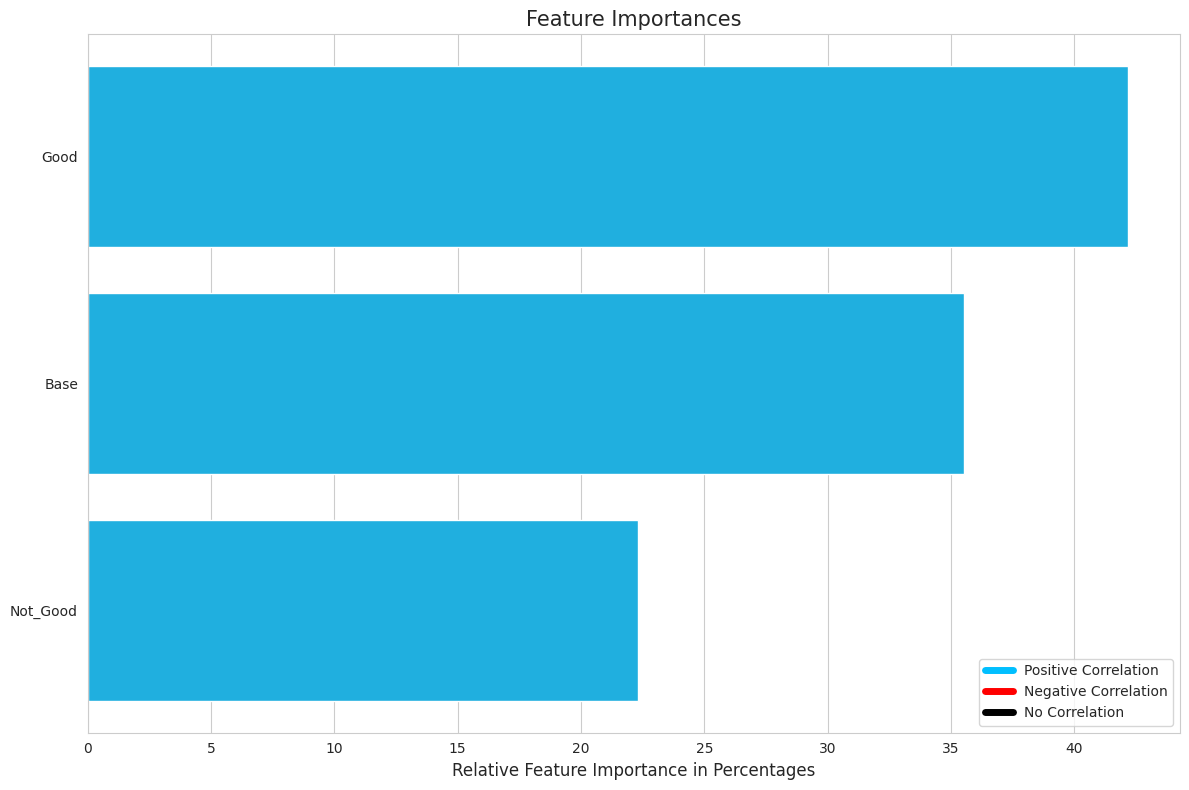

In [60]:
pipeline_meta = Pipeline_Meta()
pipeline_meta.train(x_train=x_train_meta, y_train=y_train_meta, x_test = x_test_meta, y_test = y_test_meta)

In [61]:
############ SAVE MODEL ############

model_path_meta = f'Models/meta_model_{version}.pkl'
with open(model_path_meta, 'wb') as out:
    pickle.dump(pipeline_meta.pipeline, out, pickle.HIGHEST_PROTOCOL)

In [62]:
############ ADVANCED PIPELINE RESULTS ############

meta_test_proba_dict = pipeline_meta.apply(x_test_meta, y_test_meta)
meta_test_proba = meta_test_proba_dict["".join(key for key in meta_test_proba_dict if "Logistic Regression" in key)][0]
meta_test_proba = pd.DataFrame(meta_test_proba, index = y_test_meta.index)

2024-02-09 15:31:01,656 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:31:01,657 - qnbanalytics - INFO - Train gini: 0.6096468527574443
2024-02-09 15:31:01,657 - qnbanalytics - INFO - CV gini: 0.6242263917975948
2024-02-09 15:31:01,658 - qnbanalytics - INFO - Valid gini: 0.5749948157224996
2024-02-09 15:31:01,659 - qnbanalytics - INFO - Test gini: 0.5749948157224996



In [63]:
############ APPLY TO ALL DATA ############

all_x = pd.concat([x_train,x_test], axis = 0)
all_y = pd.concat([y_train,y_test], axis = 0)

base_all_proba = pipeline_base.apply(all_x, all_y)["".join(key for key in base_test_proba_dict if "Logistic Regression" in key)][0]
not_good_all_proba = pipeline_not_good.apply(all_x, all_y)["".join(key for key in not_good_test_proba_dict if f"{not_good_selected_model}" in key)][0]
good_all_proba = pipeline_good.apply(all_x, all_y)["".join(key for key in good_test_proba_dict if f"{good_selected_model}" in key)][0]

base_all_proba = pd.DataFrame(base_all_proba, index = all_y.index)
not_good_all_proba = pd.DataFrame(not_good_all_proba, index = all_y.index)
good_all_proba = pd.DataFrame(good_all_proba, index = all_y.index)

x_all_meta = pd.concat([base_all_proba,good_all_proba,not_good_all_proba], axis = 1)
x_all_meta.columns = ["Base","Good","Not_Good"]
y_all_meta = all_y

meta_all_proba = pipeline_meta.apply(x_all_meta, y_all_meta)["".join(key for key in meta_test_proba_dict if "Logistic Regression" in key)][0]
meta_all_proba = pd.DataFrame(meta_all_proba, index = y_all_meta.index)




############ CALCULATE CREDIT SCORES ############

ref=200
odds_at_ref=100
points_to_double=20




default_rate = base_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

base_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
base_all_score = pd.DataFrame(base_all_score, index = all_y.index)




default_rate = meta_all_proba
default_rate = np.where(default_rate == 0, 0.00001, default_rate)

odds = (1/default_rate)-1

meta_all_score = ((np.log(odds)-np.log(odds_at_ref))/np.log(2)) * (points_to_double) + ref
meta_all_score = pd.DataFrame(meta_all_score, index = all_y.index)





all_scores = pd.concat([base_all_proba, base_all_score, meta_all_proba, meta_all_score, all_y], axis = 1)
all_scores.columns = ["BASIC_PROBA","BASIC_SCORE","BOOSTED_PROBA","BOOSTED_SCORE","TARGET"]
pd.DataFrame(all_scores).to_excel(f"Output/MAIN_SCORES_{version}.xlsx")


print("Runtime: %s" % (datetime.datetime.now()- start_time))

2024-02-09 15:31:12,934 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:31:12,936 - qnbanalytics - INFO - Train gini: 0.597644163943863
2024-02-09 15:31:12,937 - qnbanalytics - INFO - CV gini: 0.5677272095325383
2024-02-09 15:31:12,938 - qnbanalytics - INFO - Valid gini: 0.5630992553492318
2024-02-09 15:31:12,938 - qnbanalytics - INFO - Test gini: 0.5966651358958048

2024-02-09 15:31:19,750 - qnbanalytics - INFO - Scaling started...

2024-02-09 15:31:19,815 - qnbanalytics - INFO - Scaling completed.

2024-02-09 15:31:20,857 - qnbanalytics - INFO - Imputation transform started...
2024-02-09 15:31:20,999 - qnbanalytics - INFO - Imputation transform completed...
2024-02-09 15:31:21,032 - qnbanalytics - INFO - Encoding started...

2024-02-09 15:31:21,038 - qnbanalytics - INFO - Encoding completed.

2024-02-09 15:31:21,113 - qnbanalytics - INFO - Results of Logistic Regression
2024-02-09 15:31:21,114 - qnbanalytics - INFO - Train gini: 0.299544266631407
2024-02-09 15:31

Runtime: 0:13:35.204637
